## 06_cluster.ipynb — Phase B: Behavioural Typologies

Clusters the 39,396-user feature matrix into behavioural types using two methods
(k-means and HDBSCAN) for robustness, then validates the result. Convergence
across two paradigms is evidence the typologies are real structure, not artifacts
of one method.

### Cell 1 — Load the feature matrix

Loads `user_features.parquet` (53 features, 0–100 normalised) and separates the
column groups: 33 behavioural features vs 20 DAPT embedding components. The split
is kept for later analysis — e.g. testing whether embeddings add clustering value.

In [3]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

os.chdir("/root/tf-project/venv/Projects/BehaviouralAnalysis")
sys.path.append("src")

PROC = "data/processed"
X = pd.read_parquet(f"{PROC}/user_features.parquet")
print("matrix:", X.shape)   # (39396, 53)

# keep behavioural vs embedding column groups for later analysis
beh_cols = [c for c in X.columns if not c.startswith("emb_pc")]
emb_cols = [c for c in X.columns if c.startswith("emb_pc")]
print("behavioural:", len(beh_cols), "| embedding:", len(emb_cols))

matrix: (39396, 53)
behavioural: 33 | embedding: 20


### Cell 2 — PCA (for k-means + variance reporting)

Reduces the 53 features to 15 principal components. PCA is linear, deterministic,
and interpretable — used here for k-means input and to report variance explained
(a required methodology statistic: "the first 15 components capture X% of variance").

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15, random_state=0)
Xp = pca.fit_transform(X)

var = pca.explained_variance_ratio_
print("variance explained by 15 comps:", round(var.sum()*100, 1), "%")
for i, v in enumerate(np.cumsum(var)):
    print(f"  {i+1:2d} comps: {v*100:5.1f}%")

variance explained by 15 comps: 81.6 %
   1 comps:  15.8%
   2 comps:  30.5%
   3 comps:  40.9%
   4 comps:  47.4%
   5 comps:  52.8%
   6 comps:  57.7%
   7 comps:  62.2%
   8 comps:  66.4%
   9 comps:  70.0%
  10 comps:  72.9%
  11 comps:  75.3%
  12 comps:  77.3%
  13 comps:  78.8%
  14 comps:  80.3%
  15 comps:  81.6%


### Cell 3 — Choose k (silhouette + elbow)

Runs k-means for k = 4…12 and scores each with silhouette (cluster separation) and
inertia (elbow). The chosen k is picked defensibly from these curves, not by eye.
Proposal target is 6–10 typologies; the data confirms the exact number.

k=4: silhouette=0.151
k=5: silhouette=0.130
k=6: silhouette=0.118
k=7: silhouette=0.108
k=8: silhouette=0.102
k=9: silhouette=0.104
k=10: silhouette=0.098
k=11: silhouette=0.100
k=12: silhouette=0.098


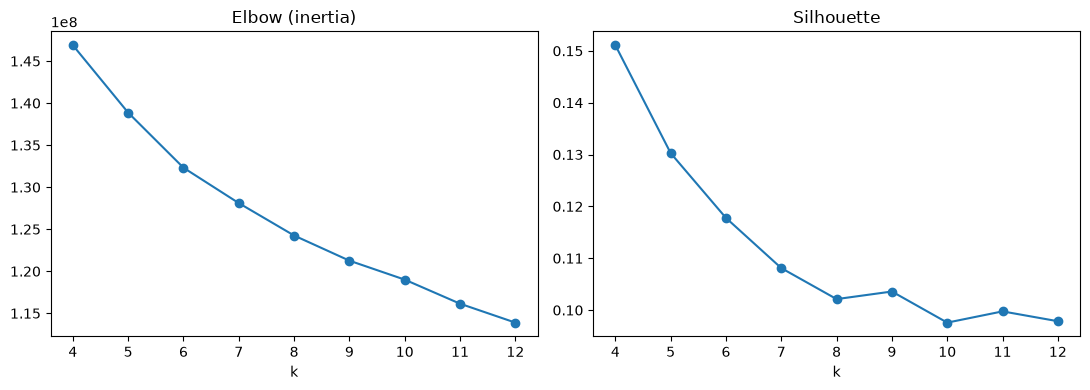

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(4, 13)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    lab = km.fit_predict(Xp)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xp, lab, sample_size=5000, random_state=0))
    print(f"k={k}: silhouette={sils[-1]:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(list(ks), inertias, "o-"); a1.set_title("Elbow (inertia)"); a1.set_xlabel("k")
a2.plot(list(ks), sils, "o-"); a2.set_title("Silhouette"); a2.set_xlabel("k")
plt.tight_layout(); plt.show()

### Cell 4 — UMAP (for HDBSCAN + visualisation)

Non-linear reduction to 15 dimensions with `min_dist=0` — produces the tight,
density-separated space HDBSCAN needs. A separate 2D UMAP is saved for the
cluster-visualisation figure. UMAP captures non-linear structure that PCA's
linear projection flattens.

In [8]:
import umap

reducer = umap.UMAP(n_components=15, n_neighbors=30, min_dist=0.0,
                    metric="euclidean", random_state=0)
Xu = reducer.fit_transform(X)
print("UMAP embedding:", Xu.shape)

# 2D version for figures
viz = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=0)
X2 = viz.fit_transform(X)
np.save(f"{PROC}/umap_2d.npy", X2)

I0000 00:00:1787761902.029545     760 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/tf-project/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding: (39396, 15)


/root/tf-project/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:
import hdbscan
import numpy as np

cl = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=25,
                     cluster_selection_method="leaf",
                     prediction_data=True)
hlab = cl.fit_predict(Xu)          # Xu = the 15-dim UMAP from Cell 4

n_clusters = hlab.max() + 1
noise = (hlab == -1).mean()
print(f"HDBSCAN clusters: {n_clusters}")
print(f"noise/outliers: {noise:.1%}")
import pandas as pd
print(pd.Series(hlab).value_counts().sort_index())

HDBSCAN clusters: 13
noise/outliers: 53.6%
-1     21131
 0       341
 1       956
 2       439
 3      1815
 4       785
 5       901
 6      1102
 7      5311
 8      1976
 9       520
 10      630
 11     1339
 12     2150
Name: count, dtype: int64


In [10]:
import pandas as pd
X = pd.read_parquet("data/processed/user_features.parquet")

# use k-means at a mid k for this test
from sklearn.cluster import KMeans
klab = KMeans(n_clusters=7, random_state=0, n_init=10).fit_predict(Xp)  # Xp = PCA from Cell 2

harm = [c for c in X.columns if any(x in c for x in
        ["victim","financial_strain","financial_spend","parasocial_fusion","escalation","_peak"])]
prof = X.groupby(klab)[harm].mean().round(2)
print(prof.T)   # rows = harm features, cols = clusters

                            0      1      2      3      4      5      6
parasocial_fusion_mean   0.76   0.80   0.95   1.16   1.08   0.12   2.49
financial_spend_mean     1.45   0.64   3.58   0.25  10.39   1.09   0.27
financial_strain_mean    0.35   0.21   0.60   0.10   1.15   0.18   0.05
victim_attack_mean       1.02   0.43   1.94   5.69   0.09   0.22   0.09
victim_invasion_mean     0.42   0.19   1.03   1.90   0.06   0.21   0.08
victim_fanwar_mean       0.59   0.33   1.81   3.59   0.12   0.18   0.10
victim_hostility_mean    1.58   0.49   2.04   5.88   0.07   0.27   0.08
victim_targeted_mean     0.09   0.05   0.13   0.34   0.01   0.01   0.01
parasocial_peak         38.66  42.67  62.08  52.64  45.68   8.66  56.19
financial_peak           9.33   8.01  54.42   5.92  58.77   7.24   4.11
victim_peak             10.08   7.53  48.59  50.54   2.50   2.90   2.48
parasocial_escalation   53.42  53.49  53.25  53.31  53.55  53.45  53.20
financial_escalation    50.12  50.39  50.64  50.31  50.91  50.36

In [11]:
import pandas as pd
X = pd.read_parquet("data/processed/user_features.parquet")
# you need each user's dominant subreddit — pull from posts_scored
df = pd.read_parquet("data/processed/posts_scored.parquet")
dom_sub = df.groupby("uid").subreddit.agg(lambda s: s.mode()[0])
klab_s = pd.Series(klab, index=X.index)
ct = pd.crosstab(klab_s, dom_sub.reindex(X.index), normalize="index")
print(ct.round(2))   # rows=cluster, cols=subreddit — is each cluster dominated by one sub?

subreddit  AKB48  BlackPink  Nogizaka46  Sakurazaka46  TwiceSnark  bangtan  \
row_0                                                                        
0           0.03       0.06        0.00           0.0        0.00     0.03   
1           0.03       0.04        0.01           0.0        0.01     0.06   
2           0.04       0.09        0.01           0.0        0.00     0.09   
3           0.02       0.03        0.00           0.0        0.01     0.02   
4           0.02       0.09        0.01           0.0        0.00     0.14   
5           0.04       0.10        0.01           0.0        0.00     0.17   
6           0.06       0.10        0.01           0.0        0.00     0.19   

subreddit  enhypen  jihyo  jpop  kpop_uncensored  kpopcollections  \
row_0                                                               
0             0.07   0.00  0.07             0.13             0.07   
1             0.02   0.00  0.03             0.21             0.01   
2             0.07   

In [12]:
import pandas as pd
X = pd.read_parquet("data/processed/user_features.parquet")
df = pd.read_parquet("data/processed/posts_scored.parquet")

# each user's main subreddit
dom_sub = df.groupby("uid").subreddit.agg(lambda s: s.mode()[0])

# klab = your k-means labels from the last cell
klab_s = pd.Series(klab, index=X.index)
ct = pd.crosstab(klab_s, dom_sub.reindex(X.index), normalize="index")
print(ct.round(2))

subreddit  AKB48  BlackPink  Nogizaka46  Sakurazaka46  TwiceSnark  bangtan  \
row_0                                                                        
0           0.03       0.06        0.00           0.0        0.00     0.03   
1           0.03       0.04        0.01           0.0        0.01     0.06   
2           0.04       0.09        0.01           0.0        0.00     0.09   
3           0.02       0.03        0.00           0.0        0.01     0.02   
4           0.02       0.09        0.01           0.0        0.00     0.14   
5           0.04       0.10        0.01           0.0        0.00     0.17   
6           0.06       0.10        0.01           0.0        0.00     0.19   

subreddit  enhypen  jihyo  jpop  kpop_uncensored  kpopcollections  \
row_0                                                               
0             0.07   0.00  0.07             0.13             0.07   
1             0.02   0.00  0.03             0.21             0.01   
2             0.07   

In [13]:
import pandas as pd
X = pd.read_parquet("data/processed/user_features.parquet")

names = {0:"Broadly Engaged", 1:"Casual Participant", 2:"High-Intensity Multi-Domain",
         3:"Conflict-Exposed", 4:"Financially Intensive Collector",
         5:"Peripheral", 6:"Devoted"}
fan = {0:"Active Fan", 1:"Casual Stan", 2:"Hardcore Multi-Stan", 3:"Fanwar-Embroiled",
       4:"Collector/Whale", 5:"Lurker", 6:"Ult-Devoted"}

out = pd.DataFrame({"uid": X.index, "cluster": klab})
out["type"] = out.cluster.map(names)
out["fan_term"] = out.cluster.map(fan)
out.to_parquet("data/processed/user_clusters.parquet")
print(out.type.value_counts().sort_index())

type
Broadly Engaged                    2834
Casual Participant                 6866
Conflict-Exposed                   5937
Devoted                            5969
Financially Intensive Collector    8660
High-Intensity Multi-Domain        4670
Peripheral                         4460
Name: count, dtype: int64


In [14]:
import pandas as pd
X = pd.read_parquet("data/processed/user_features.parquet")
df = pd.read_parquet("data/processed/posts_scored.parquet")

# each user's main subreddit
dom_sub = df.groupby("uid").subreddit.agg(lambda s: s.mode()[0])

# klab = your k-means labels from the last cell
klab_s = pd.Series(klab, index=X.index)
ct = pd.crosstab(klab_s, dom_sub.reindex(X.index), normalize="index")
print(ct.round(2))

subreddit  AKB48  BlackPink  Nogizaka46  Sakurazaka46  TwiceSnark  bangtan  \
row_0                                                                        
0           0.03       0.06        0.00           0.0        0.00     0.03   
1           0.03       0.04        0.01           0.0        0.01     0.06   
2           0.04       0.09        0.01           0.0        0.00     0.09   
3           0.02       0.03        0.00           0.0        0.01     0.02   
4           0.02       0.09        0.01           0.0        0.00     0.14   
5           0.04       0.10        0.01           0.0        0.00     0.17   
6           0.06       0.10        0.01           0.0        0.00     0.19   

subreddit  enhypen  jihyo  jpop  kpop_uncensored  kpopcollections  \
row_0                                                               
0             0.07   0.00  0.07             0.13             0.07   
1             0.02   0.00  0.03             0.21             0.01   
2             0.07   

## Visualizing the scatter

### Figure 1 : UMAP cluster projection

Plots all 39,396 users in 2D (UMAP), coloured by behavioural type. Shows how the
seven clusters occupy the behavioural space. Some overlap is expected and honest —
it reflects the continuum structure found in the silhouette analysis (fan behaviour
is gradient, not sharply partitioned). Saved to `clusters_umap.png`.

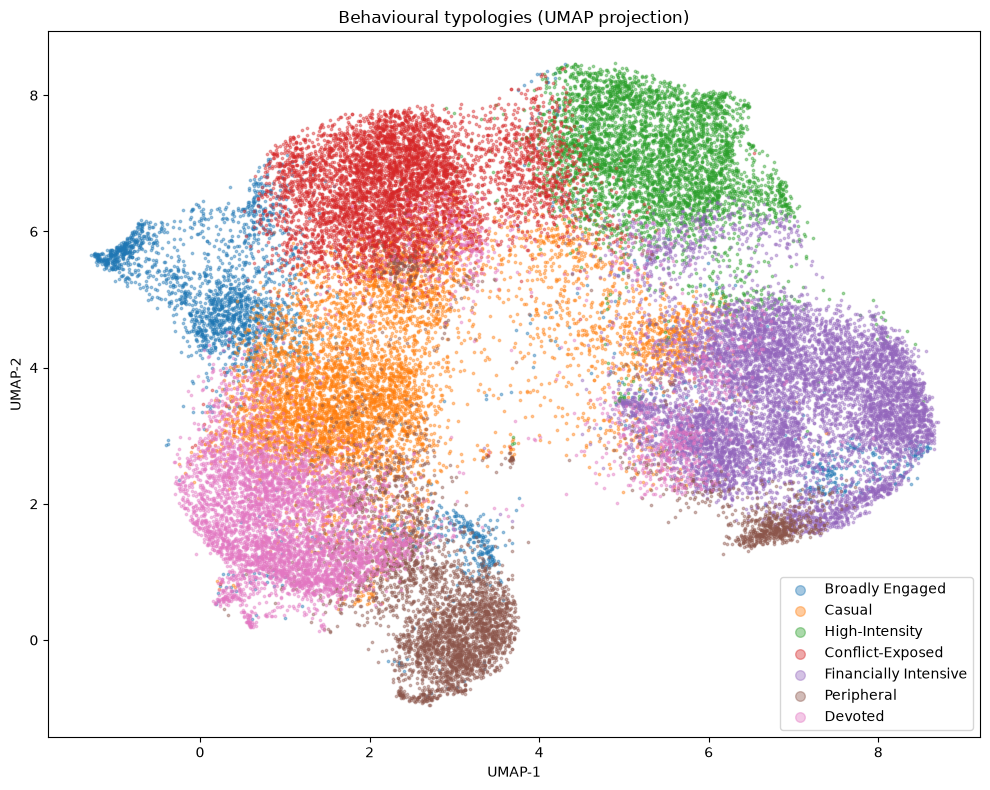

In [15]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

X2 = np.load("data/processed/umap_2d.npy")
cl = pd.read_parquet("data/processed/user_clusters.parquet")

names = {0:"Broadly Engaged",1:"Casual",2:"High-Intensity",3:"Conflict-Exposed",
         4:"Financially Intensive",5:"Peripheral",6:"Devoted"}

fig, ax = plt.subplots(figsize=(10,8))
for c in sorted(cl.cluster.unique()):
    m = cl.cluster.values == c
    ax.scatter(X2[m,0], X2[m,1], s=3, alpha=0.4, label=names[c])
ax.legend(markerscale=4, loc="best")
ax.set_title("Behavioural typologies (UMAP projection)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.savefig("data/processed/clusters_umap.png", dpi=150)
plt.show()

## The harm heatmap 

### Figure 2 : Harm-feature heatmap (headline result)

Shows which behavioural type concentrates which kind of harm. Each cell is a
harm feature's mean for that type; colour is z-scored so red = over-represented,
blue = under-represented. This is the core finding: harm modalities are
type-specific — Conflict-Exposed lights up on victimisation, Financially Intensive
on spending — proving the typology discriminates *different kinds* of harm rather
than a single "at-risk" axis. Saved to `harm_heatmap.png`.

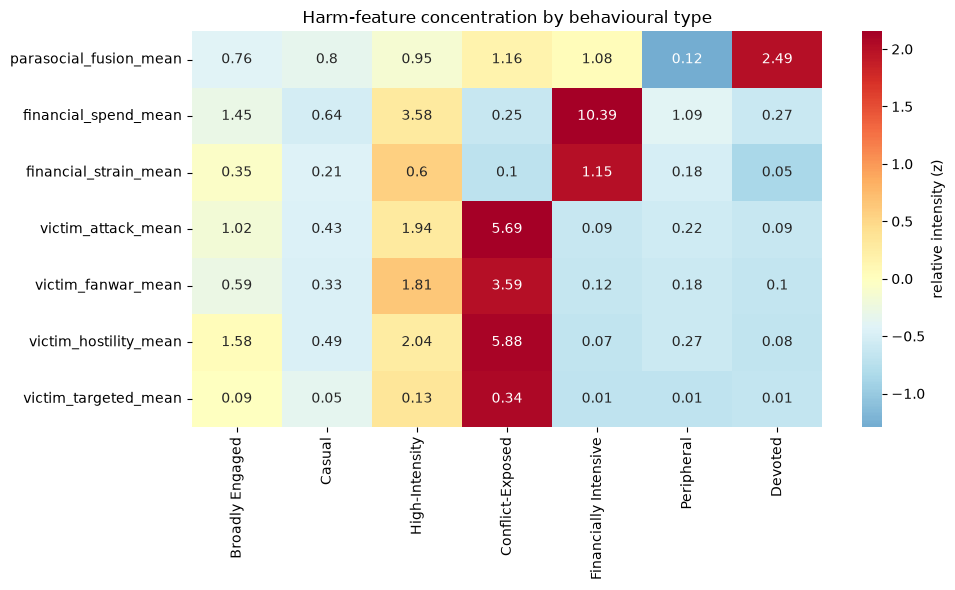

In [16]:
import seaborn as sns

X = pd.read_parquet("data/processed/user_features.parquet")
klab = cl.set_index("uid").reindex(X.index).cluster

harm = ["parasocial_fusion_mean","financial_spend_mean","financial_strain_mean",
        "victim_attack_mean","victim_fanwar_mean","victim_hostility_mean","victim_targeted_mean"]
prof = X.groupby(klab)[harm].mean()
prof.index = [names[i] for i in prof.index]

# z-score each feature so colours show relative concentration
profz = (prof - prof.mean()) / prof.std()

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(profz.T, cmap="RdYlBu_r", center=0, annot=prof.T.round(2),
            fmt="g", cbar_kws={"label":"relative intensity (z)"}, ax=ax)
ax.set_title("Harm-feature concentration by behavioural type")
plt.tight_layout(); plt.savefig("data/processed/harm_heatmap.png", dpi=150)
plt.show()

### Figure 3 : Cluster sizes

Bar chart of how many users fall into each behavioural type. Confirms the
partition is balanced (7–22% per type) with no runaway majority or negligible
cluster evidence that k=7 found genuine, populated types. Saved to
`cluster_sizes.png`.

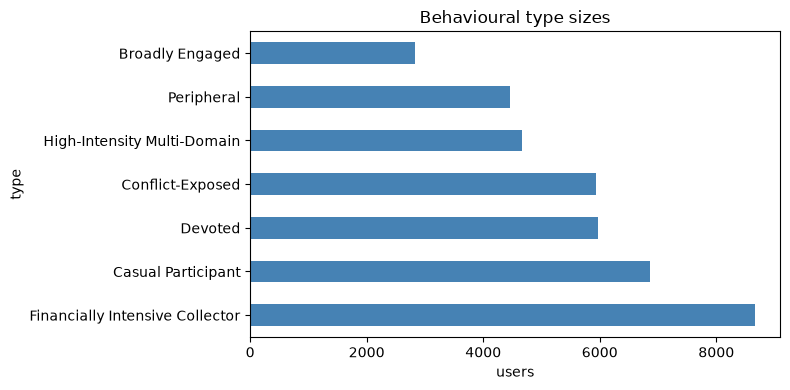

In [17]:
sizes = cl.type.value_counts()
sizes.plot(kind="barh", figsize=(8,4), color="steelblue")
plt.xlabel("users"); plt.title("Behavioural type sizes")
plt.tight_layout(); plt.savefig("data/processed/cluster_sizes.png", dpi=150); plt.show()

## Behavioural types across fandom demographics (secondary analysis)

Exploratory overlay: how the seven *behavioural* types distribute across genre
(K-pop / J-pop) and group-gender (boy / girl / mixed). The behavioural typology
remains primary — this asks how those types spread across fandom demographics,
not a re-clustering by group. Sampling is uneven (more girl-group and K-pop
communities were scraped), so all figures use within-group proportions and the
imbalance is stated in interpretation.

### Tag users with genre + group-gender

Maps each subreddit to (genre, group-gender), then assigns every user the tags of
their dominant subreddit. `SUB_META` must cover all 20 subreddits — the value_counts
check flags any left as MISSING (which would silently default and skew results).

In [18]:
import pandas as pd

# classify your subreddits — edit these to match reality
SUB_META = {
    "bangtan":        ("K-pop","boy"),
    "straykids":      ("K-pop","boy"),
    "enhypen":        ("K-pop","boy"),
    "BlackPink":      ("K-pop","girl"),
    "twice":          ("K-pop","girl"),
    "nayeon":         ("K-pop","girl"),
    "jihyo":          ("K-pop","girl"),
    "AKB48":          ("J-pop","girl"),
    "Nogizaka46":     ("J-pop","girl"),
    "Sakurazaka46":   ("J-pop","girl"),
    "jpop":           ("J-pop","mixed"),
    "kpop_uncensored":("K-pop","mixed"),
    "kpopcollections":("K-pop","mixed"),
    "kpoprants":      ("K-pop","mixed"),
    "kpoptrulyuncensored":("K-pop","mixed"),
    "kpopharshopinions":("K-pop","mixed"),
    "unpopularkpopopinions":("K-pop","mixed"),
    "TwiceSnark":     ("K-pop","girl"),
}

# assign each user their dominant subreddit's genre + gender
df = pd.read_parquet("data/processed/posts_scored.parquet")
dom_sub = df.groupby("uid").subreddit.agg(lambda s: s.mode()[0])
meta = dom_sub.map(lambda s: SUB_META.get(s, ("K-pop","mixed")))
user_meta = pd.DataFrame({"uid": dom_sub.index,
                          "genre": [m[0] for m in meta],
                          "gender": [m[1] for m in meta]}).set_index("uid")

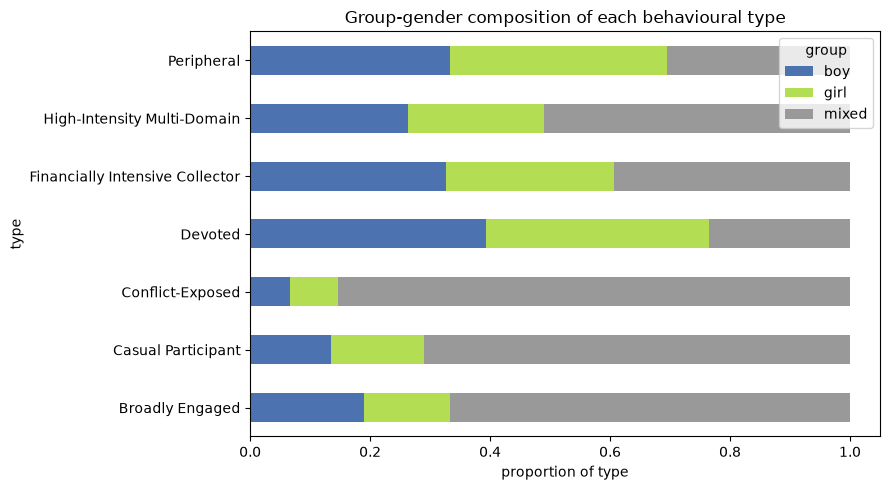

In [30]:
import matplotlib.pyplot as plt
cl = pd.read_parquet("data/processed/user_clusters.parquet").set_index("uid")
m = cl.join(user_meta)

ct = pd.crosstab(m.type, m.gender, normalize="index")
ct.plot(kind="barh", stacked=True, figsize=(9,5),
        color={"boy":"#4C72B0","girl":"#B3DD52","mixed":"#999999"})
plt.title("Group-gender composition of each behavioural type")
plt.xlabel("proportion of type"); plt.legend(title="group")
plt.tight_layout(); plt.savefig("data/processed/type_by_gender.png", dpi=150); plt.show()

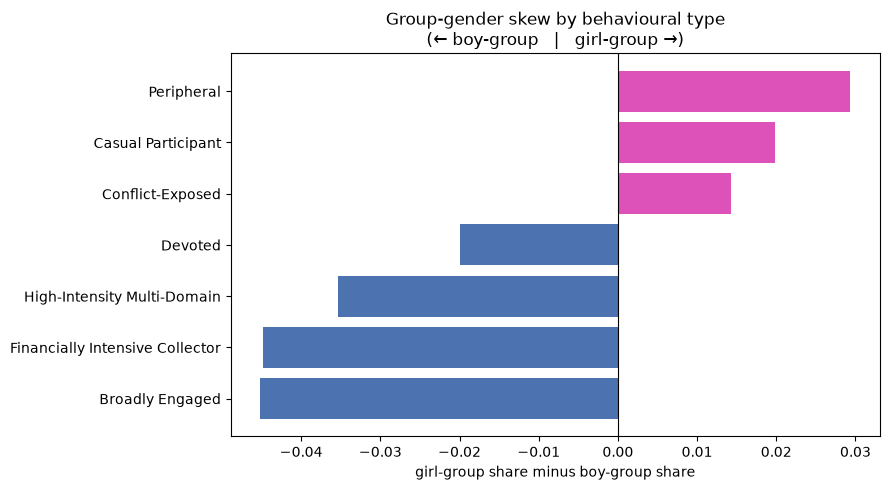

In [33]:
skew = ct["girl"] - ct["boy"]           # positive = girl-skewed, negative = boy-skewed
skew = skew.sort_values()
colors = ["#4C72B0" if v < 0 else "#DD52B8" for v in skew]

plt.figure(figsize=(9,5))
plt.barh(skew.index, skew.values, color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.title("Group-gender skew by behavioural type\n(← boy-group   |   girl-group →)")
plt.xlabel("girl-group share minus boy-group share")
plt.tight_layout(); plt.savefig("data/processed/type_gender_skew.png", dpi=150); plt.show()

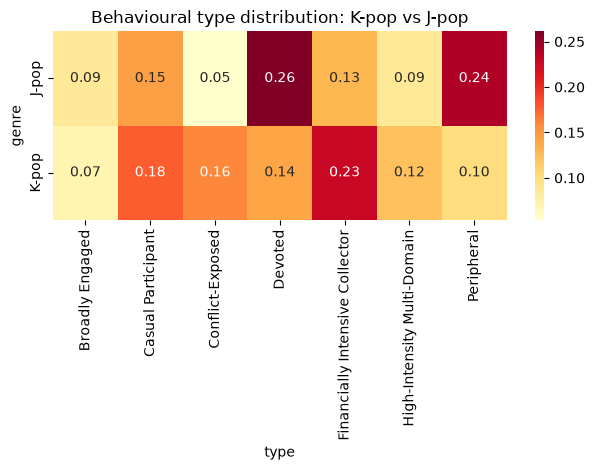

In [20]:
import seaborn as sns
ct2 = pd.crosstab(m.genre, m.type, normalize="index")
sns.heatmap(ct2, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Behavioural type distribution: K-pop vs J-pop")
plt.tight_layout(); plt.savefig("data/processed/genre_type.png", dpi=150); plt.show()

In [26]:
import pandas as pd

# assemble everything: features + cluster type + genre/gender, keyed by user
X  = pd.read_parquet("data/processed/user_features.parquet")
cl = pd.read_parquet("data/processed/user_clusters.parquet").set_index("uid")

# user_meta was built earlier (genre, gender per user)
m = X.join(cl[["type"]]).join(user_meta)      # features + type + genre + gender

# fandom-health summary per genre (or swap "genre" for "gender")
group_health = m.groupby("genre").agg(
    n_users=("type", "count"),
    pct_high_strain=("financial_strain_mean", lambda x: (x > x.quantile(0.90)).mean()),
    pct_conflict_exposed=("type", lambda t: (t == "Conflict-Exposed").mean()),
    pct_devoted=("type", lambda t: (t == "Devoted").mean()),
    pct_high_intensity=("type", lambda t: (t == "High-Intensity Multi-Domain").mean()),
)
# healthy-to-harmful attachment ratio
group_health["devoted_harmful_ratio"] = (
    group_health["pct_devoted"] / group_health["pct_high_intensity"].replace(0, 1)
)
print(group_health.round(3))


       n_users  pct_high_strain  pct_conflict_exposed  pct_devoted  \
genre                                                                
J-pop     3384            0.048                 0.054        0.261   
K-pop    36012            0.083                 0.160        0.141   

       pct_high_intensity  devoted_harmful_ratio  
genre                                             
J-pop               0.086                  3.038  
K-pop               0.122                  1.161  


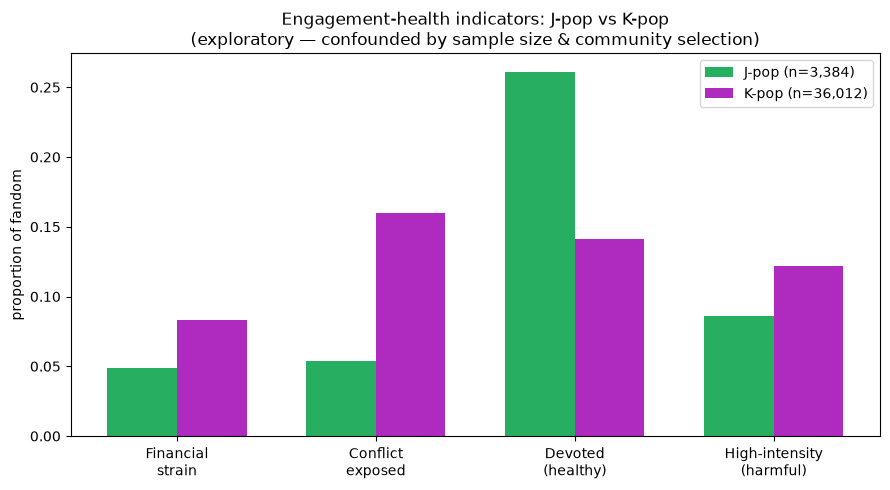

In [35]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["pct_high_strain", "pct_conflict_exposed", "pct_devoted", "pct_high_intensity"]
labels = ["Financial\nstrain", "Conflict\nexposed", "Devoted\n(healthy)", "High-intensity\n(harmful)"]
jpop = group_health.loc["J-pop", metrics].values
kpop = group_health.loc["K-pop", metrics].values

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x-w/2, jpop, w, label="J-pop (n=3,384)", color="#27AE60")
ax.bar(x+w/2, kpop, w, label="K-pop (n=36,012)", color="#AF2BC0")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("proportion of fandom")
ax.set_title("Engagement-health indicators: J-pop vs K-pop\n(exploratory — confounded by sample size & community selection)")
ax.legend()
plt.tight_layout(); plt.savefig("data/processed/jpop_vs_kpop.png", dpi=150); plt.show()

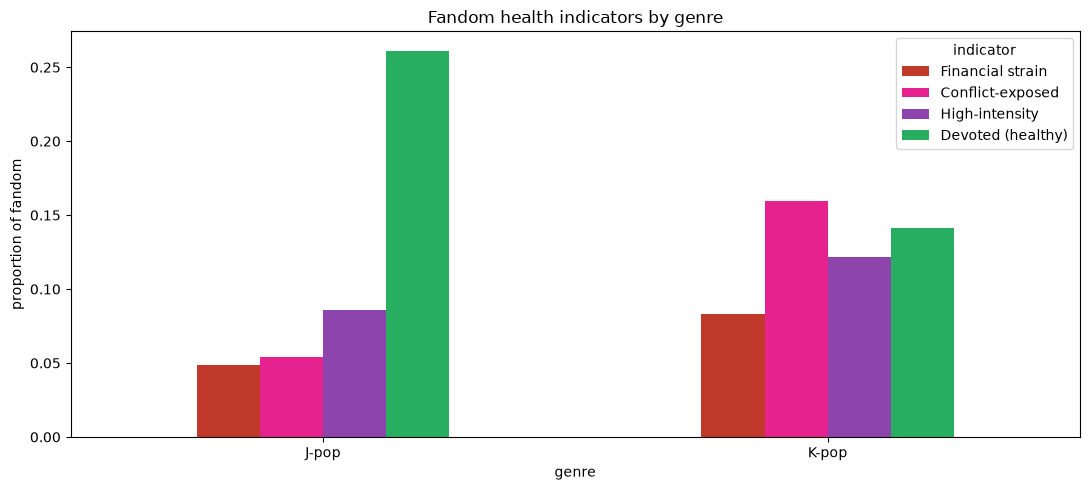

In [34]:
import matplotlib.pyplot as plt

# the harm-signal columns to compare (drop count + ratio for this chart)
cols = ["pct_high_strain", "pct_conflict_exposed", "pct_high_intensity", "pct_devoted"]
labels = ["Financial strain", "Conflict-exposed", "High-intensity", "Devoted (healthy)"]

ax = group_health[cols].plot(kind="bar", figsize=(11,5),
        color=["#C0392B", "#E6228E", "#8E44AD", "#27AE60"])
ax.set_xticklabels(group_health.index, rotation=0)
ax.set_ylabel("proportion of fandom")
ax.set_title("Fandom health indicators by genre")
ax.legend(labels, title="indicator")
plt.tight_layout(); plt.savefig("data/processed/fandom_health.png", dpi=150); plt.show()

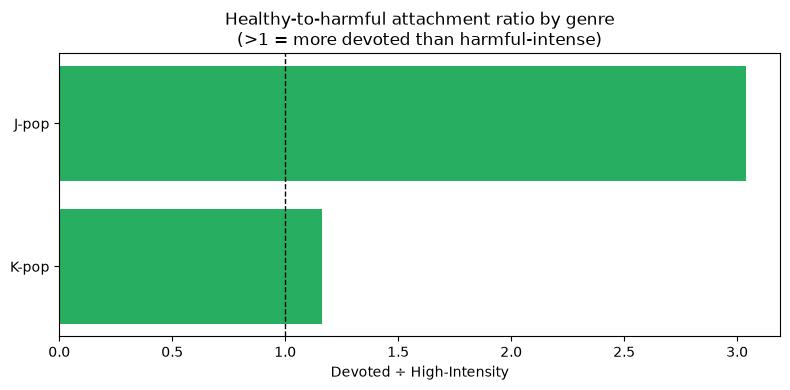

In [28]:
import matplotlib.pyplot as plt

r = group_health["devoted_harmful_ratio"].sort_values()
colors = ["#C0392B" if v < 1 else "#27AE60" for v in r]  # <1 = more harmful, >1 = more healthy

plt.figure(figsize=(8,4))
plt.barh(r.index, r.values, color=colors)
plt.axvline(1, color="black", lw=1, ls="--")   # 1.0 = balanced
plt.title("Healthy-to-harmful attachment ratio by genre\n(>1 = more devoted than harmful-intense)")
plt.xlabel("Devoted ÷ High-Intensity")
plt.tight_layout(); plt.savefig("data/processed/health_ratio.png", dpi=150); plt.show()